# Notebook 02: Interim Data Exploration & Feature Engineering Decisions

## Purpose
This notebook explores the cleaned interim datasets creating in preprocessing: `src/preprocess.py`:
- `data/interim/data_centers_cleaned.gpkg`
- `data/interim/epa_superfund_deduplicated.gpkg`

The goal is to validate preprocessing output, understand the analytical
structure of both datasets, and make decisions about feature engineering that would be necessary for spatial analysis. The analysis in this notebooks contributes to the feature engineering in the script:
`src/build_features.py`.

## Inputs
- `data/interim/data_centers_cleaned.gpkg` — read with `gpd.read_file()`
- `data/interim/epa_superfund_deduplicated.gpkg` — read with `gpd.read_file()`



In [29]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import contextily as ctx

from src.tufte_style import define_plot_style
from src.tufte_style import COLORS, STATUS_PALETTE, REGION_PALETTE, EO_PALETTE

In [30]:
plt.style.use('seaborn-v0_8-whitegrid')
define_plot_style()

In [31]:
INTERIM_DIR = "../data/interim/"
DATA_CENTERS_FILE = "data_centers_cleaned.gpkg"
SUPERFUND_FILE = "superfund_deduplicated.gpkg"
dc_df = gpd.read_file(os.path.join(INTERIM_DIR, DATA_CENTERS_FILE))
sf_df = gpd.read_file(os.path.join(INTERIM_DIR, SUPERFUND_FILE))

## Validation: Preprocessing Output

Before exploration we confirm the interim files loaded correctly:
- DC geometry type: all `Point` (1,473 rows) ✓
- SF geometry type: all `MultiPolygon` (1,908 rows) ✓
- Both datasets CRS: `EPSG:4326` ✓
- Key dtypes confirmed: `date_created` → datetime64, `lat`/`long` → float64,
  `post_eo` → bool, `invalid_coords` → bool


In [32]:
dc_df.head()

,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,info_source_8,date_created,date_updated,invalid_coords,source_count,census_region,post_eo,days_since_eo,location_confidence_flag,geometry
0,Project Marvel,Rock Mountain Lake Rd,Bessemer,AL,35022.0,Jefferson,33.342000,-87.034100,Proposed,High,...,None,2025-09-16,2026-03-13,False,7,South,True,77.0,1,POINT (-87.0341 33.342)
1,DC Blox,433 6th St S,Birmingham,AL,35233.0,Jefferson,33.500510,-86.821000,Operating,High,...,None,2025-08-25,2025-08-25,False,0,South,True,55.0,1,POINT (-86.821 33.50051)
2,Google Data Center,48809 Alabama 277,Bridgeport,AL,35740.0,Jackson,34.920190,-85.744600,Operating,High,...,None,2025-07-15,2026-02-18,False,2,South,True,14.0,1,POINT (-85.7446 34.92019)
3,Western Hospitality Partners Data Center,Childersburg Industrial Park,Childersburg,AL,35044.0,Talladega,33.340885,-86.336205,Proposed,Medium,...,None,2026-01-26,2026-01-26,False,2,South,True,209.0,0,POINT (-86.3362 33.34088)
4,DC Blox,333 Diamond Dr NW,Huntsville,AL,35806.0,Madison,34.710030,-86.693000,Operating,High,...,None,2025-08-25,2025-08-25,False,0,South,True,55.0,1,POINT (-86.693 34.71003)


In [33]:
print("DC DF dtypes: ")
print(dc_df.dtypes)
print("SF DF dtypes")
print(sf_df.dtypes)


DC DF dtypes: 
facility_name                        object
address                              object
city                                 object
state                                object
zip                                  object
county                               object
lat                                 float64
long                                float64
status                               object
location_confidence                  object
purpose                              object
operator_name                        object
tenant                               object
mw                                  float64
sizerank                            float64
power_source                         object
dedicated_power_plant                object
number_of_generators                float64
number_of_buildings                 float64
cooling_source                       object
cooling_type                         object
facility_size_sqft                  float64
property_size_acr

In [34]:
# confirm geometry types are what we expect
print(dc_df.geometry.geom_type.value_counts())   # should be all Point
print(sf_df.geometry.geom_type.value_counts())   # should be Polygon/MultiPolygon
print(dc_df.crs)                                 # EPSG:4326
print(sf_df.crs)                                 # EPSG:4326

Point    1473
Name: count, dtype: int64
MultiPolygon    1908
Name: count, dtype: int64
EPSG:4326
EPSG:4326


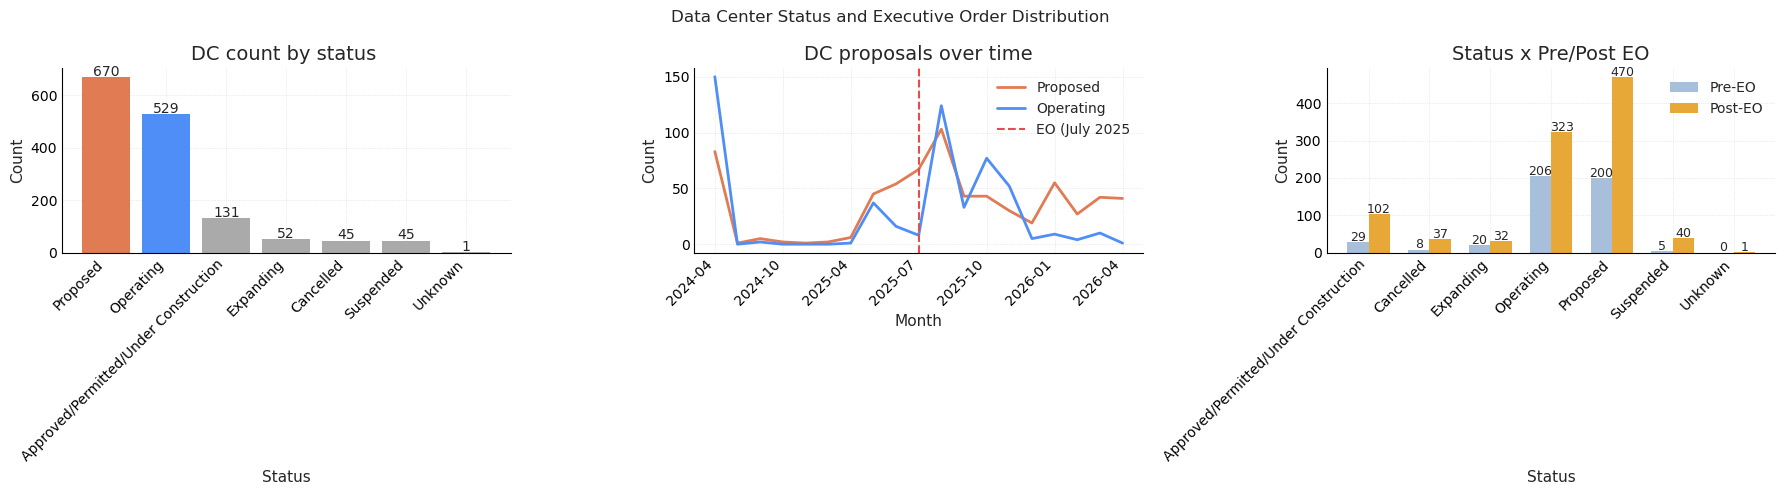

In [35]:
# DC Status and EO Distribution

# - Overall status breakdown across all DCs
# - DC creation over time with EO cutoff marked
# - Status × pre/post EO crosstab

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Data Center Status and Executive Order Distribution", fontsize=12)
status_counts = dc_df["status"].value_counts()
axes[0].bar(
    status_counts.index,
    status_counts.values,
    color=[STATUS_PALETTE.get(s, COLORS['neutral']) for s in status_counts.index]
)
axes[0].set_title("DC count by status ")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Count")
for i, val in enumerate(status_counts.values):
    axes[0].text(i, val + 5,f"{val:,}", ha="center")

monthly = (
    dc_df.groupby([dc_df["date_created"].dt.to_period("M"), "status"]).size().unstack(fill_value=0)
)
for status, color in STATUS_PALETTE.items():
    if status in monthly.columns:
        axes[1].plot(
            monthly.index.astype(str),
            monthly[status],
            label=status,
            color=color,
            linewidth=2
        )
eo_period = str(pd.Period("2025-07", "M"))
if eo_period in monthly.index.astype(str):
    eo_x = list(monthly.index.astype(str)).index(eo_period)
    axes[1].axvline(eo_x, color=COLORS["highlight"], linestyle="--", linewidth="1.5", label="EO (July 2025")
axes[1].set_title("DC proposals over time")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")

ticks = axes[1].get_xticks()
axes[1].set_xticks(ticks[::3])
axes[1].legend()

crosstab = pd.crosstab(dc_df["status"], dc_df["post_eo"])
crosstab.columns = ["Pre-EO", "Post-EO"]

x = np.arange(len(crosstab.index))
width = 0.35
bars_pre = axes[2].bar(x - width / 2, crosstab["Pre-EO"], width, label="Pre-EO", color=COLORS['pre_eo'])
bars_post = axes[2].bar(x + width/ 2, crosstab["Post-EO"], width, label="Post-EO", color=COLORS['post_eo'])
axes[2].set_title("Status x Pre/Post EO")
axes[2].set_xlabel("Status")
axes[2].set_ylabel("Count")
axes[2].set_xticks(x)
axes[2].set_xticklabels(crosstab.index)
axes[2].legend()
for bar in [*bars_pre, *bars_post]:
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=9
    )
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [36]:
# ── Compute rates dynamically ─────────────────────────────────────
EO_DATE = pd.Timestamp("2025-07-01")

pre_eo_days  = (EO_DATE - dc_df["date_created"].min()).days
post_eo_days = (dc_df["date_created"].max() - EO_DATE).days

pre_proposed  = (~dc_df["post_eo"] & (dc_df["status"] == "Proposed")).sum()
post_proposed = (dc_df["post_eo"]  & (dc_df["status"] == "Proposed")).sum()

pre_rate  = pre_proposed  / pre_eo_days
post_rate = post_proposed / post_eo_days
multiplier = post_rate / pre_rate

# ── Summary stats ─────────────────────────────────────────────────
print("\nStatus breakdown:")
print(dc_df["status"].value_counts())
print(f"\nStatus × Pre/Post EO:\n{crosstab}")
print(f"\nPre-EO  proposed count: {pre_proposed}  over {pre_eo_days} days")
print(f"Post-EO proposed count: {post_proposed} over {post_eo_days} days")
print(f"\nPre-EO  proposal rate:  {pre_rate:.2f} per day")
print(f"Post-EO proposal rate:  {post_rate:.2f} per day")
print(f"Rate multiplier: {multiplier:.1f}x")


Status breakdown:
status
Proposed                                 670
Operating                                529
Approved/Permitted/Under Construction    131
Expanding                                 52
Cancelled                                 45
Suspended                                 45
Unknown                                    1
Name: count, dtype: int64

Status × Pre/Post EO:
                                       Pre-EO  Post-EO
status                                                
Approved/Permitted/Under Construction      29      102
Cancelled                                   8       37
Expanding                                  20       32
Operating                                 206      323
Proposed                                  200      470
Suspended                                   5       40
Unknown                                     0        1

Pre-EO  proposed count: 200  over 447 days
Post-EO proposed count: 470 over 296 days

Pre-EO  proposal rate:  0.45

In [37]:
# create status groups

# ── 1d: Status group breakdown ────────────────────────────────────
status_group_map = {
    "Proposed"                             : "In Pipeline",
    "Approved/Permitted/Under Construction": "In Pipeline",
    "Expanding"                            : "In Pipeline",
    "Operating"                            : "Operating",
    "Cancelled"                            : "Inactive",
    "Suspended"                            : "Inactive",
    "Unknown"                              : "Inactive",
}
dc_df["status_group"] = dc_df["status"].map(status_group_map)

print(dc_df["status_group"].value_counts())
print(f"\nStatus group × Pre/Post EO:\n{pd.crosstab(dc_df['status_group'], dc_df['post_eo'])}")

status_group
In Pipeline    853
Operating      529
Inactive        91
Name: count, dtype: int64

Status group × Pre/Post EO:
post_eo       False  True 
status_group              
In Pipeline     249    604
Inactive         13     78
Operating       206    323


## 1: Distribution of Data Center Status Before and After the Executive Order



### Key findings:
Counts for each status category:

| Status | N |
|---|---|
| Proposed | 670 |
| Operating | 529 |
| Approved/Permitted/Under Construction | 131 |
| Expanding | 52 |
| Cancelled | 45 |
| Suspended | 45 |
| Unknown | 1 |

### Decision — status_group:
Per the decision in the last notebook, the status group is collapsed into three analytical groups to simplify the research question.  The `In Pipeline` status captures the categories relate to active development and are relevant to the EO research question. Every status category increased post-EO, which might the EO accelerated activity across the entire development pipeline.

| status_group | Statuses | N |
|---|---|---|
| In Pipeline | Proposed, Approved/Permitted/Under Construction, Expanding | 853 |
| Operating | Operating | 529 |
| Inactive | Cancelled, Suspended, Unknown | 91 |



### Executive Order finding:
The daily rate of proposed data center projects increased 3.5x after the
July 2025 EO:
- Pre-EO: 0.45 proposals/day (200 over 447 days)
- Post-EO: 1.59 proposals/day (470 over 296 days)

**Important caveat:** The time series reveals a large spike in April 2024
(101 entries in a single month) which probably might bulk data entry rather than an actual proposal date.

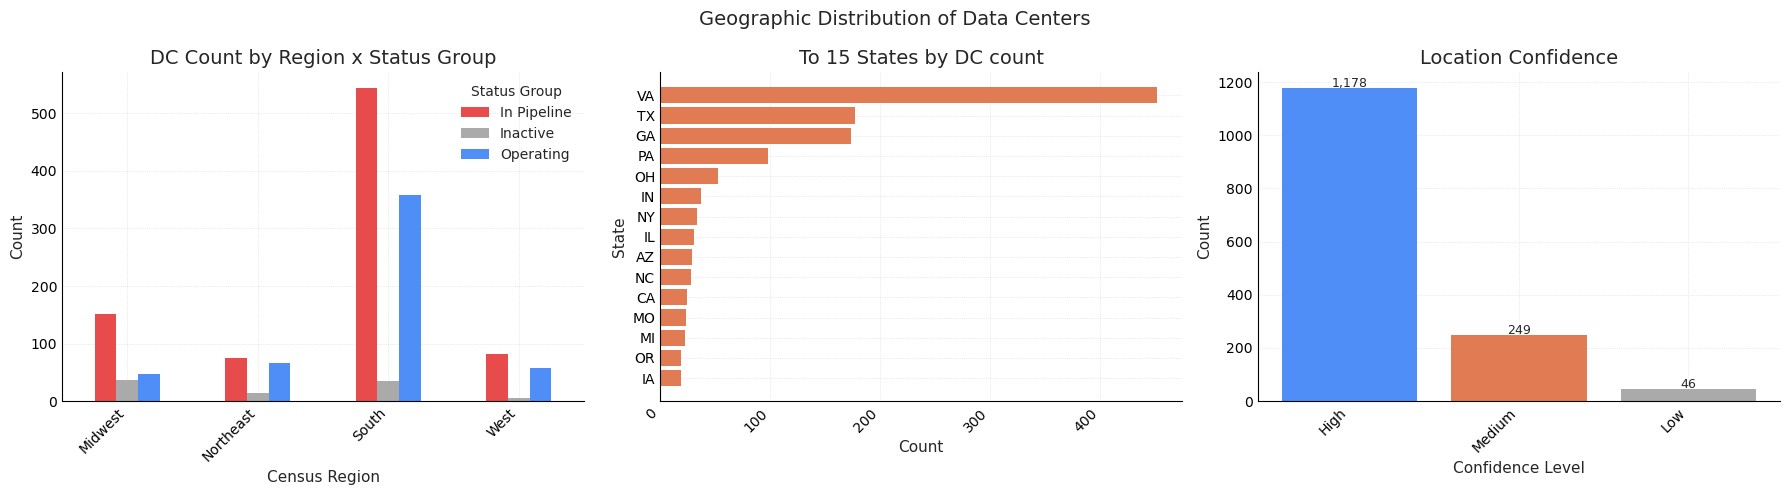

In [39]:
# Geographic Distribution of DCs
# - DC count by census region × status group
# - Top 15 states by DC count
# - Location confidence breakdown

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Geographic Distribution of Data Centers", fontsize=14)

region_status = pd.crosstab(dc_df["census_region"], dc_df["status_group"])
region_status.plot(
    kind="bar",
    ax=axes[0],
    color=[COLORS["highlight"], COLORS["neutral"], COLORS["operating"]]
)
axes[0].set_title("DC Count by Region x Status Group")
axes[0].set_xlabel("Census Region")
axes[0].set_ylabel("Count")
axes[0].legend(title="Status Group")

top_states = dc_df["state"].value_counts().head(15)
va_count = top_states.get("VA", 0)
top_states_no_va = top_states[top_states.index != "VA"].head(15)
axes[1].barh(
    top_states.index[::-1],
    top_states.values[::-1],
    color=COLORS["proposed"]
)

axes[1].set_title("To 15 States by DC count")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("State")


conf_counts = dc_df["location_confidence"].str.strip().str.title().value_counts()
axes[2].bar(
    conf_counts.index,
    conf_counts.values,
    color=[COLORS["operating"], COLORS["proposed"], COLORS["neutral"]]
)
axes[2].set_title("Location Confidence")
axes[2].set_xlabel("Confidence Level")
axes[2].set_ylabel("Count")
for i, val in enumerate(conf_counts.values):
    axes[2].text(i, val + 3, f"{val:,}", ha="center", fontsize=9)
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [40]:
print("\n DCs by census region: ")
print(dc_df["census_region"].value_counts())
print(f"\nStatus group x census region: \n {pd.crosstab(dc_df['census_region'], dc_df['status_group'])}")
print(f"\nTop 15 States:\n{top_states}")
print(f"\nLocation confidence:\n{conf_counts}")
print(f"Unmapped states (no census region):")
print(dc_df[dc_df["census_region"].isnull()]["state"].value_counts())


 DCs by census region: 
census_region
South        937
Midwest      237
Northeast    155
West         144
Name: count, dtype: int64

Status group x census region: 
 status_group   In Pipeline  Inactive  Operating
census_region                                  
Midwest                152        37         48
Northeast               75        14         66
South                  544        35        358
West                    82         5         57

Top 15 States:
state
VA    452
TX    177
GA    174
PA     98
OH     53
IN     37
NY     34
IL     31
AZ     29
NC     28
CA     25
MO     24
MI     23
OR     19
IA     19
Name: count, dtype: int64

Location confidence:
location_confidence
High      1178
Medium     249
Low         46
Name: count, dtype: int64
Unmapped states (no census region):
Series([], Name: count, dtype: int64)


2: Geographic Distribution of Data Centers

### Key findings:

**Regional skew:**
The South accounts for 63% of all DCs (937 of 1,473), driven by Virginia
(452 DCs — Northern Virginia/Ashburn is the world's largest data center market).

| Region | N | In Pipeline | Operating |
|---|---|---|---|
| South | 937 | 544 | 358 |
| Midwest | 237 | 152 | 48 |
| Northeast | 155 | 75 | 66 |
| West | 144 | 82 | 57 |

**Top 5 states:** VA (452), TX (177), GA (174), PA (98), OH (53)

**Location confidence:**
- High: 1,178 (80%) ✓
- Medium: 249 (17%)
- Low: 46 (3%)

Note: Review location confidence because Low/Medium confidence is concentrated in the  `In Pipeline` status (258) vs Operating (7). This makes sense because proposed data centers have less verified location data. Consider a `location_confidence_flag` variable
(1 = High, 0 = Medium/Low).

### Decision:
No states were excluded based on geography at this stage. Virginia is noted
as a dominant outlier in visualizations but retained in analysis. Sensitivity
analysis excluding VA is possible if needed.

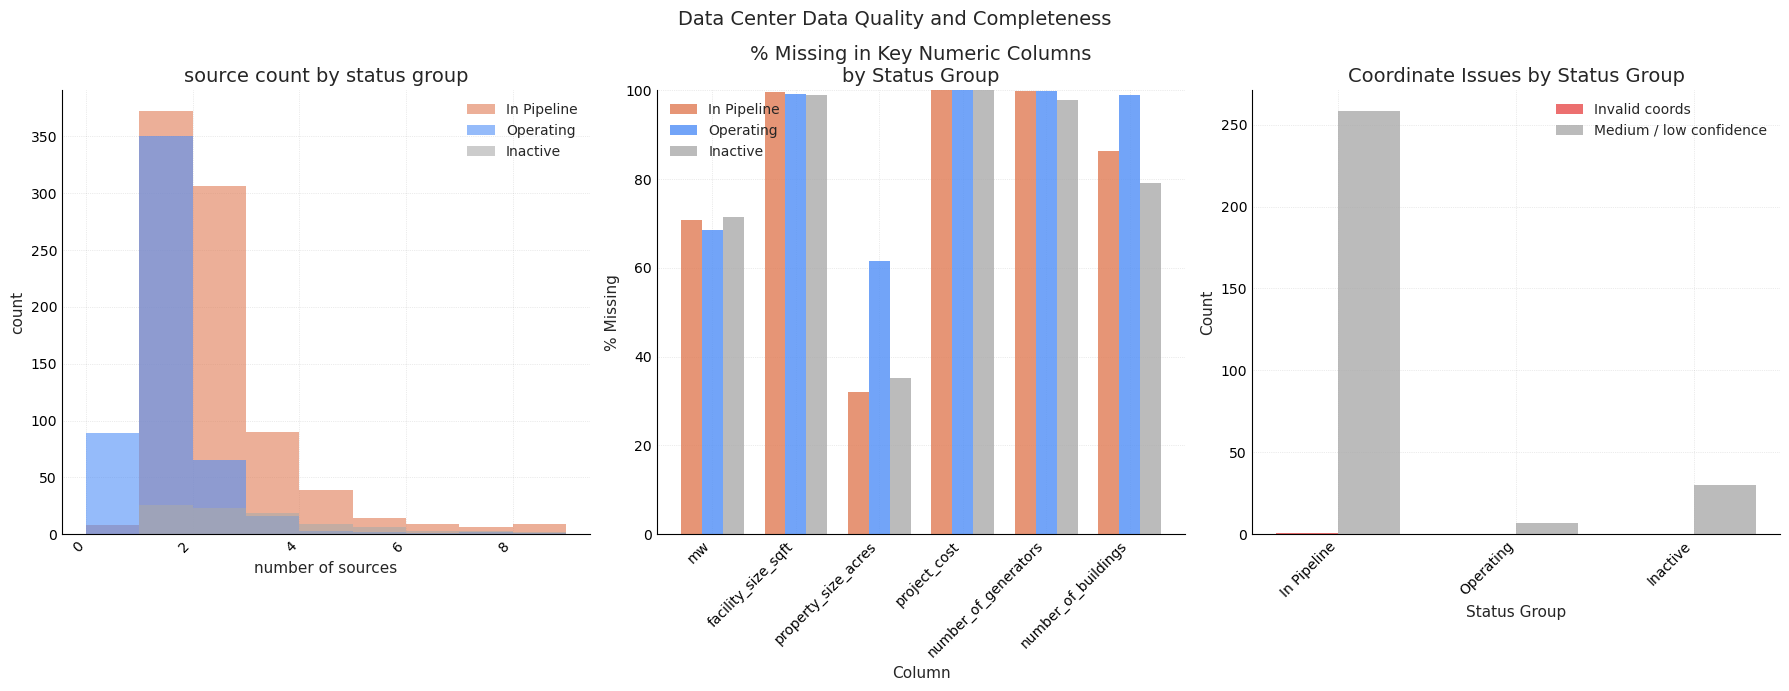

In [41]:
# DC Data Quality and Completeness
# - Source count distribution by status group
# - Missingness of key numeric columns by status group
# - Coordinate issues by status group


fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Data Center Data Quality and Completeness", fontsize=14)

source_palette = {
    "In Pipeline": COLORS["proposed"],
    "Operating":   COLORS["operating"],
    "Inactive":    COLORS["neutral"],
}

for group, color in source_palette.items():
    subset = dc_df[dc_df["status_group"] == group]["source_count"]
    axes[0].hist(
        subset,
        bins=range(0, dc_df["source_count"].max() + 2),
        alpha=0.6,
        label=group,
        color=color
    )
axes[0].set_title("source count by status group")
axes[0].set_xlabel("number of sources")
axes[0].set_ylabel("count")
axes[0].legend()

# missing numeric columns by group
key_cols = ["mw", "facility_size_sqft", "property_size_acres",
            "project_cost", "number_of_generators", "number_of_buildings"]
missing_pct = (
    dc_df.groupby("status_group")[key_cols].apply(lambda x: x.isnull().mean() * 100).T
)
x = np.arange(len(key_cols))
width = 0.25
for i, (group, color) in enumerate(source_palette.items()):
    if group in missing_pct.columns:
        axes[1].bar(
            x + i * width,
            missing_pct[group],
            width,
            label=group,
            color=color,
            alpha=0.8
        )
axes[1].set_title("% Missing in Key Numeric Columns\nby Status Group")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("% Missing")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(key_cols)
axes[1].legend()
axes[1].set_ylim(0, 100)

# invalid coords + locatioin confidence by status group
invalid_by_group = dc_df.groupby("status_group")["invalid_coords"].sum()
conf_low_by_group = (
    dc_df[dc_df["location_confidence_flag"] == 0].groupby("status_group").size()
)
x = np.arange(len(source_palette))
width = 0.35
axes[2].bar(
    x - width / 2,
    [invalid_by_group.get(g, 0) for g in source_palette],
    width,
    label="Invalid coords",
    color=COLORS["highlight"],
    alpha=0.8,
)

axes[2].bar(
    x + width / 2,
    [conf_low_by_group.get(g, 0) for g in source_palette],
    width,
    label="Medium / low confidence",
    color=COLORS["neutral"],
    alpha=0.8,

)
axes[2].set_title("Coordinate Issues by Status Group")
axes[2].set_xlabel("Status Group")
axes[2].set_ylabel("Count")
axes[2].set_xticks(x)
axes[2].set_xticklabels(list(source_palette.keys()))
axes[2].legend()

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [42]:
print("Invalid coordinates by status group: ")
print(invalid_by_group)
print(f"\n Low / Medium confidence by status group")
print(conf_low_by_group)
print(f"\n Source count by status group: ")
print(dc_df.groupby("status_group")["source_count"].describe().round(2))
print(f"\n% Missing in key numeric columns by status group: ")
print(missing_pct.round(1))

Invalid coordinates by status group: 
status_group
In Pipeline    1
Inactive       0
Operating      0
Name: invalid_coords, dtype: int64

 Low / Medium confidence by status group
status_group
In Pipeline    258
Inactive        30
Operating        7
dtype: int64

 Source count by status group: 
              count  mean   std  min  25%  50%  75%  max
status_group                                            
In Pipeline   853.0  1.93  1.28  0.0  1.0  2.0  2.0  8.0
Inactive       91.0  2.75  1.76  1.0  1.0  2.0  3.5  8.0
Operating     529.0  1.09  0.89  0.0  1.0  1.0  1.0  8.0

% Missing in key numeric columns by status group: 
status_group          In Pipeline  Inactive  Operating
mw                           70.8      71.4       68.4
facility_size_sqft           99.5      98.9       99.2
property_size_acres          32.0      35.2       61.6
project_cost                100.0     100.0      100.0
number_of_generators         99.8      97.8       99.8
number_of_buildings          86.3     

## Beat 3: DC Data Quality & Completeness


### Source count findings:

Note: The `In Pipeline DCs` are better documented on average than `Operating` ones,
likely because proposed projects attract more media and community coverage.
`source_count` is retained as a data quality covariate in causal models.

### Decision:
As noted in the last notebook, this dataset is better for spatial proximity than for building characteristics given the large missingness of facility data.  `mw` and `property_size_acres` are
retained as optional covariates but treated with caution given high missingness.

### Coordinate issues:
- Invalid coordinates: 1 DC in `In Pipeline` — flagged, not dropped
- Low/Medium confidence: 258 In Pipeline vs 7 Operating
- These rows are retained but `location_confidence_flag` controls for
  data quality in models

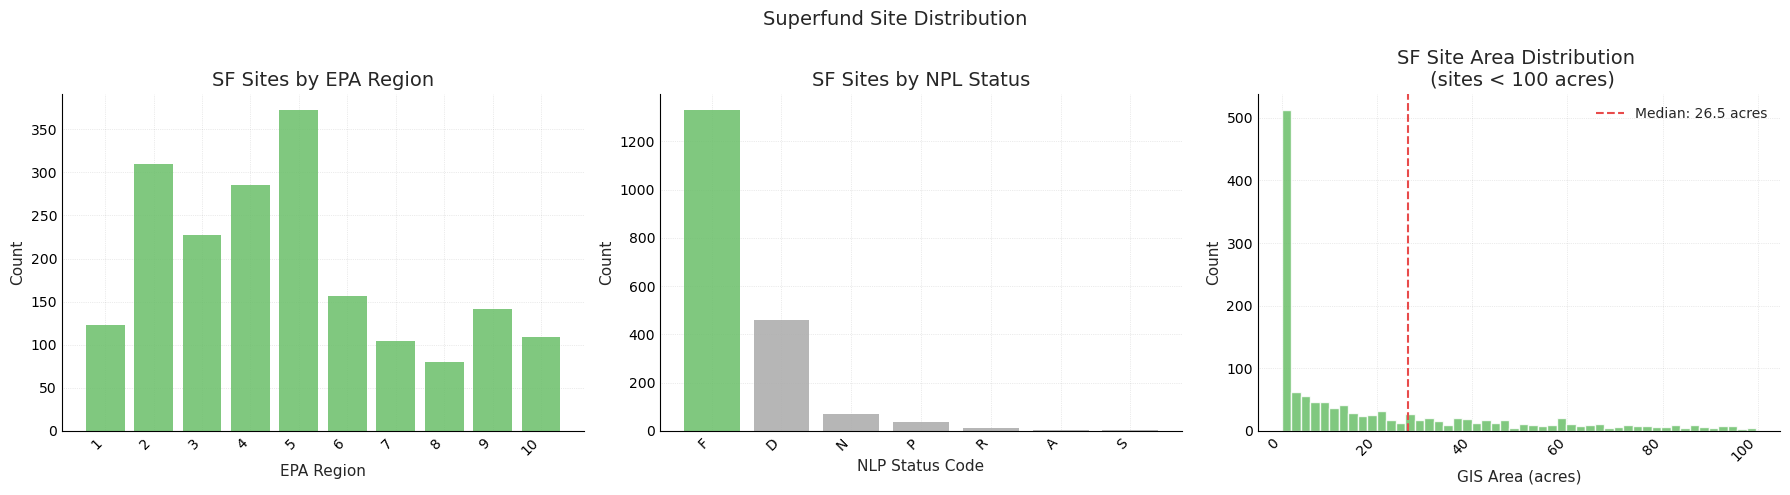

In [43]:
# SF Site Distribution
# - SF sites by EPA region
# - NPL status breakdown
# - GIS_AREA distribution

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Superfund Site Distribution", fontsize=14)
region_counts = sf_df["REGION_CODE"].value_counts().sort_index()
axes[0].bar(
    region_counts.index.astype(int).astype(str),
    region_counts.values,
    color=COLORS["superfund"],
    alpha=0.85,

)
axes[0].set_title("SF Sites by EPA Region")
axes[0].set_xlabel("EPA Region")
axes[0].set_ylabel("Count")

# nlp status breakdown
npl_counts = sf_df["NPL_STATUS_CODE"].str.strip().value_counts()
axes[1].bar(
    npl_counts.index,
    npl_counts.values,
    color=[COLORS["superfund"] if s == "F" else COLORS["neutral"] for s in npl_counts.index],
    alpha=0.85,
)

axes[1].set_title("SF Sites by NPL Status")
axes[1].set_xlabel("NLP Status Code")
axes[1].set_ylabel("Count")

# cap at 99th percentile to avoid extreme outliers
# area_cap = sf_df["GIS_AREA"].quantile(0.90)
area_cap = 100
area_data = sf_df[sf_df["GIS_AREA"] <= area_cap]["GIS_AREA"].dropna()
axes[2].hist(
    area_data,
    bins=50,
    color=COLORS["superfund"],
    alpha=0.85,
    edgecolor="white"
)
axes[2].axvline(
    sf_df["GIS_AREA"].median(),
    color=COLORS["highlight"],
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {sf_df['GIS_AREA'].median():.1f} acres",
)
# axes[2].set_title("SF Site Area Distribution \n (capped at 90th percentile)")
axes[2].set_title("SF Site Area Distribution \n (sites < 100 acres)")
axes[2].set_xlabel("GIS Area (acres)")
axes[2].set_ylabel("Count")
axes[2].legend()
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [44]:
print("SF sites by EPA region: ")
print(region_counts)
print(f"\nNPL status breakdown: ")
print(npl_counts)
print(f" Final NPL (NPL_final = 1): {sf_df['npl_final'].sum():,}")
print(f"Non-final: {(sf_df['npl_final'] ==0).sum():,}")
print("\nGIS_AREA stats (acres)")
print(sf_df['GIS_AREA'].describe().round(2))
print(f"99 percentile: {area_cap:.1f} acres")
print(f"Sites > 1000 acres: {(sf_df['GIS_AREA'] < 1000 ).sum() } ")
print(f"Sites with null GIS_AREAs { sf_df['GIS_AREA'].isnull().sum() }")

print(f"\nSITE_FEATURE_TYPE after deduplication:")
print(sf_df["SITE_FEATURE_TYPE"].value_counts())


SF sites by EPA region: 
REGION_CODE
1.0     123
2.0     310
3.0     227
4.0     285
5.0     372
6.0     157
7.0     104
8.0      80
9.0     141
10.0    109
Name: count, dtype: int64

NPL status breakdown: 
NPL_STATUS_CODE
F    1328
D     459
N      70
P      36
R      10
A       3
S       2
Name: count, dtype: int64
 Final NPL (NPL_final = 1): 1,328
Non-final: 580

GIS_AREA stats (acres)
count       1888.00
mean        3679.76
std        48304.52
min            0.00
25%            1.07
50%           26.51
75%          137.57
max      1129743.77
Name: GIS_AREA, dtype: float64
99 percentile: 100.0 acres
Sites > 1000 acres: 1708 
Sites with null GIS_AREAs 20

SITE_FEATURE_TYPE after deduplication:
SITE_FEATURE_TYPE
Comprehensive Site Area                       785
Current Ground Boundary                       488
Total Site Polygon/OU Aggregation             184
Site Boundary                                 170
Extent of Contamination                       146
OU Boundary Aggregation    

In [45]:
print(f"\nGIS_AREA_ACRES stats (acres):")
print(sf_df["GIS_AREA_ACRES"].describe().round(2))
print(f"  99th percentile: {sf_df['GIS_AREA_ACRES'].quantile(0.99):.1f} acres")
print(f"  Sites > 1000 acres: {(sf_df['GIS_AREA_ACRES'] > 1000).sum()}")
print(f"  Sites with null GIS_AREA_ACRES: {sf_df['GIS_AREA_ACRES'].isnull().sum()}")
print(f"  Linear sites excluded from area: {sf_df['linear_site'].sum()}")


GIS_AREA_ACRES stats (acres):
count       1755.00
mean        5789.57
std        54201.87
min            0.00
25%           13.88
50%           56.53
75%          245.03
max      1129743.77
Name: GIS_AREA_ACRES, dtype: float64
  99th percentile: 99320.5 acres
  Sites > 1000 acres: 238
  Sites with null GIS_AREA_ACRES: 153
  Linear sites excluded from area: 138


In [46]:
print(sf_df[["SITE_NAME", "GIS_AREA", "GIS_AREA_UNITS"]].sort_values("GIS_AREA", ascending=False).head(20))
print(sf_df["GIS_AREA_UNITS"].value_counts())

                                             SITE_NAME      GIS_AREA  \
1834                       FOX RIVER NRDA/PCB RELEASES  1.129744e+06   
391      IDAHO NATIONAL ENGINEERING LABORATORY (USDOE)  1.082653e+06   
3                                      FORT WAINWRIGHT  9.198958e+05   
762           TITTABAWASSEE RIVER, SAGINAW RIVER & BAY  7.267633e+05   
943                              ARSENIC TRIOXIDE SITE  5.970255e+05   
1356                         TAR CREEK (OTTAWA COUNTY)  3.101731e+05   
188                          CENTRAL CITY, CLEAR CREEK  2.524090e+05   
1375                                   HARBOR OIL INC.  1.562188e+05   
885                               ANACONDA CO. SMELTER  1.339313e+05   
1252                                 HUDSON RIVER PCBS  8.823405e+04   
2                               ADAK NAVAL AIR STATION  8.124948e+04   
876                                LIBBY ASBESTOS SITE  7.750875e+04   
4                             FORT RICHARDSON (USARMY)  5.973716

## Beat 4: Superfund Site Distribution


### EPA region distribution:
Region 5 (Great Lakes/Midwest) has the most sites (372), followed by
Region 4 (Southeast, 285) and Region 2 (NY/NJ, 310).

### NPL status breakdown:
| Code | Meaning | N |
|---|---|---|
| F | Final NPL | 1,328 |
| D | Deleted | 459 |
| N | Not on NPL | 70 |
| P | Proposed | 36 |
| Other | R, A, S | 15 |

**Note**: Deleted sites (D, 459) are sites removed from the NPL
priority list. These sites are useful to the research question and should be examined in sensitivity analsysi because they are useful to the question of whether the EPA accelerates deletions to make room for data center development.

### GIS_AREA findings:
After unit normalization (Acres/Square Miles/Miles → all acres):
- Median: 56.5 acres (~0.3 mile radius)
- 239 sites > 1,000 acres
- 138 linear sites (GIS_AREA_UNITS = "Miles") — flagged with `linear_site = 1`
  Note: despite this flag, all geometries are MultiPolygon. The "Miles" unit
  reflects very small polygon sites, not true linear geometries.
- 20 sites with null GIS_AREA — noted in methods, not dropped

### Decision — distance thresholds:
The median SF site footprint (~0.3 mile radius) informed our choice of
distance thresholds. A 1 mile threshold extends meaningfully beyond the
typical site boundary (and matches the MIT study cited in our background.)
This notebook focuses on using: 0.5, 1, 3, and 5 miles as proximity measures:
- **Primary threshold: 1 mile** — EPA precedent, literature match
- **Secondary threshold: 3 miles** — better statistical power (N~3x larger)
- 0.5 and 5 miles reported for sensitivity

/tmp/ipykernel_27739/1608356398.py:45: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[0].legend(loc='lower right', markerscale=2)


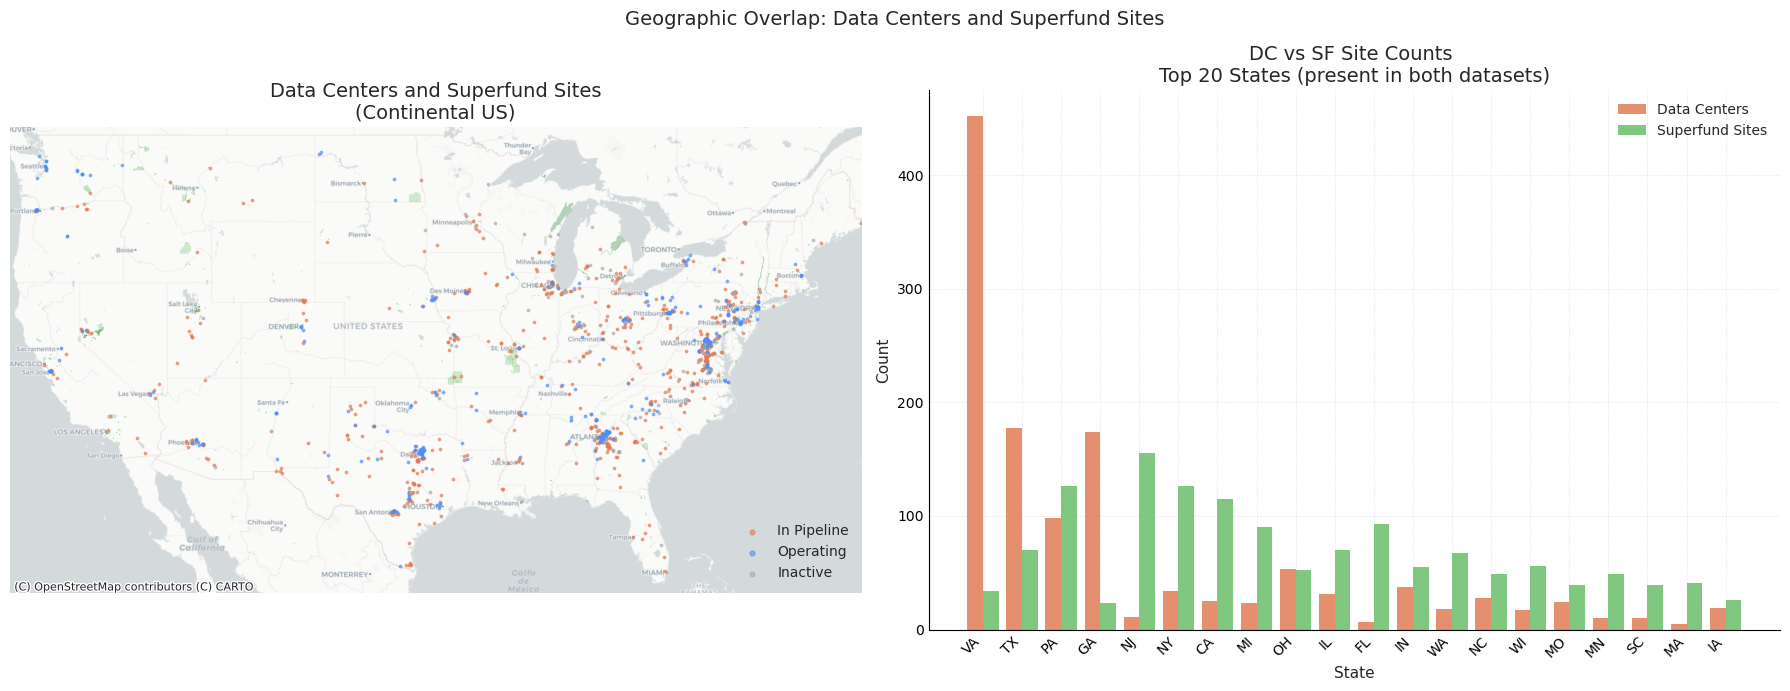

In [47]:
# Cross dataset Geography Overlap
# - Map of DC points over SF polygons (continental US)
# - DC vs SF site counts by state

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Geographic Overlap: Data Centers and Superfund Sites", fontsize=14)

dc_web = dc_df[~dc_df['invalid_coords']].to_crs(epsg=3857)
sf_web = sf_df[sf_df["geometry"].notnull()].to_crs(epsg=3857)

CONUS_BOUNDS = {
    "minx": -13884029, "maxx": -7453304,
    "miny":  2818228,  "maxy":  6335621,
}

# Plot SF polygons first
sf_web.plot(
    ax=axes[0],
    color=COLORS["superfund"],
    alpha=0.3,
    linewidth=0.3,
    edgecolor=COLORS['superfund'],
    label="Superfund Sites"
)

# Plot DC points on top, colored by status group
status_group_palette = {
    'In Pipeline': COLORS['proposed'],
    'Operating': COLORS['operating'],
    'Inactive': COLORS['neutral'],
}

for group, color in status_group_palette.items():
    subset = dc_web[dc_web["status_group"] == group]
    subset.plot(
        ax=axes[0],
        color=color,
        markersize=3,
        alpha=0.6,
        label=group,
    )

# US continental bounds
axes[0].set_xlim(CONUS_BOUNDS['minx'], CONUS_BOUNDS['maxx'])
axes[0].set_ylim(CONUS_BOUNDS['miny'], CONUS_BOUNDS['maxy'])
axes[0].set_title("Data Centers and Superfund Sites\n(Continental US)")
axes[0].set_axis_off()
axes[0].legend(loc='lower right', markerscale=2)

try:
    ctx.add_basemap(
        axes[0],
        source=ctx.providers.CartoDB.Positron,
        zoom=5,
    )
except Exception as e:
    print(f" Basemap unavailable: {e}")

dc_by_state = dc_df['state'].value_counts()
sf_by_state = sf_df['STATE_CODE'].str.strip().value_counts()

common_states = (
    set(dc_by_state.index) & set(sf_by_state.index)
)
# comparison df
compare_df = pd.DataFrame(
    {
        "Data Centers": dc_by_state,
        "Superfund Sites": sf_by_state,
    }
).fillna(0).astype(int)

compare_df = (
    compare_df[compare_df.index.isin(common_states)].assign(
        total=lambda x: x.sum(axis=1)).sort_values("total",
                                                   ascending=False).drop(
        columns="total").head(20))
x = np.arange(len(compare_df))
width = 0.4

axes[1].bar(
    x - width / 2,
    compare_df['Data Centers'],
    width,
    label="Data Centers",
    color=COLORS['proposed'],
    alpha=0.85
)
axes[1].bar(
    x + width / 2,
    compare_df['Superfund Sites'],
    width,
    label = 'Superfund Sites',
    color = COLORS['superfund'],
    alpha=0.85
)
axes[1].set_title("DC vs SF Site Counts \nTop 20 States (present in both datasets)")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Count")
axes[1].set_xticks(x)
axes[1].set_xticklabels(compare_df.index)
axes[1].legend()
for ax in axes[1:]:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [48]:
print(f"States with DCs: {dc_df['state'].nunique() }")
print(f"States with SF sites: {sf_df['STATE_CODE'].str.strip().nunique() }")
print(f"States present in both datasets: {len(common_states)  }")

print(f"\nStates with DCs but no SF sites:")
dc_only = set(dc_by_state.index) - set(sf_by_state.index)
print(sorted(dc_only))

print(f"\nStates with SF sites but no DCs:")
sf_only = set(sf_by_state.index) - set(dc_by_state.index)
print(sorted(sf_only))

print(f"\n Top 10 states by SF site count: ")
print(sf_by_state.head(10))

States with DCs: 47
States with SF sites: 57
States present in both datasets: 47

States with DCs but no SF sites:
[]

States with SF sites but no DCs:
['AK', 'AS', 'DC', 'FM', 'GU', 'MP', 'PR', 'RI', 'VI', 'VT']

 Top 10 states by SF site count: 
STATE_CODE
NJ    155
NY    126
PA    126
CA    115
FL     93
MI     90
IL     70
TX     70
WA     67
WI     56
Name: count, dtype: int64


## Beat 5: Cross-Dataset Geographic Overlap


### Key findings:
- States with SF sites but no DCs: AK, RI, VT and US territories
  (AS, GU, PR, VI) — territories
- Every state with a data center has at least one superfund site
- NJ has the most SF sites (155) but very few DCs — interesting contrast
- VA has the most DCs (452) but relatively few SF sites

### Top states by SF site count:
NJ (155), NY (126), PA (126), CA (115), FL (93), MI (90)

### Visual observation:
- The continental US map shows DC clustering in Northern Virginia, Atlanta,
Chicago corridor, and Dallas/Houston.
- The Northeast (NJ, PA, NY) shows dense overlap of both datasets,
suggesting it as a high-risk region for proximity.

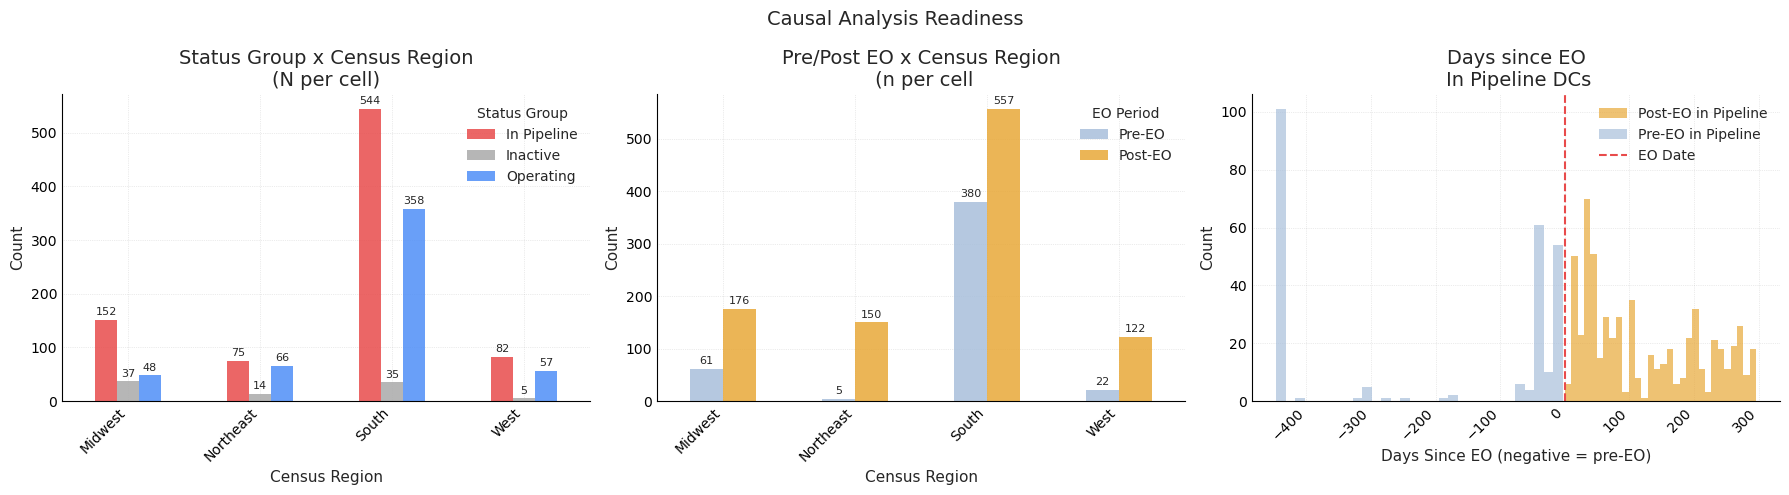

In [49]:
# Causal Readiness - do we have the right data, and enough data for causal analysis?
# - Status group × census region cell counts
# - Pre/post EO × census region cell counts
# - `days_since_eo` distribution for In Pipeline DCs

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Causal Analysis Readiness", fontsize=14)
region_group = pd.crosstab(
    dc_df['census_region'],
    dc_df['status_group']
)

region_group.plot(
    kind='bar',
    ax=axes[0],
    color=[COLORS['highlight'], COLORS['neutral'], COLORS['operating']],
    alpha=0.85
)
axes[0].set_title('Status Group x Census Region\n(N per cell)')
axes[0].set_xlabel('Census Region')
axes[0].set_ylabel('Count')
axes[0].legend(title='Status Group')

for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=8, padding=2)

# pre/post eo x region
eo_region = pd.crosstab(
    dc_df['census_region'],
    dc_df['post_eo'],
)

eo_region.columns = ['Pre-EO', 'Post-EO']
eo_region.plot(
    kind='bar',
    ax=axes[1],
    color=[COLORS['pre_eo'], COLORS['post_eo']],
    alpha=0.85
)
axes[1].set_title("Pre/Post EO x Census Region\n (n per cell")
axes[1].set_xlabel("Census Region")
axes[1].set_ylabel("Count")
axes[1].legend(title="EO Period")

for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=8, padding=2)

# days insce_eo distribution for In pipeline DCs
pipeline_post = dc_df[
    (dc_df['status_group'] == 'In Pipeline') &
    (dc_df['post_eo'] == True) &
    (dc_df['days_since_eo'].notnull())
]['days_since_eo']

pipeline_pre = dc_df[
    (dc_df['status_group'] == 'In Pipeline') &
    (dc_df['post_eo'] == False) &
    (dc_df['days_since_eo'].notnull())
]['days_since_eo']

axes[2].hist(
    pipeline_post,
    bins=30,
    color=COLORS['post_eo'],
    alpha=0.7,
    label="Post-EO in Pipeline"
)

axes[2].hist(
    pipeline_pre,
    bins=30,
    color=COLORS['pre_eo'],
    alpha=0.7,
    label='Pre-EO in Pipeline',
)

axes[2].axvline(0, color=COLORS['highlight'], linestyle='--', linewidth=1.5, label='EO Date')
axes[2].set_title('Days since EO\n In Pipeline DCs')
axes[2].set_xlabel("Days Since EO (negative = pre-EO)")
axes[2].set_ylabel("Count")
axes[2].legend()

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [50]:
print("Status group x census region: ")
print(region_group)
print(f"\nMin N per cell: {region_group.min().min()}")
print(f"Cells with n < 30: {(region_group < 30).sum().sum()}")

print(f"Pre/Post EO x census region: ")
eo_region_full = pd.crosstab(
    dc_df['census_region'],
    dc_df['post_eo'],
    margins=True
)
eo_region_full.columns = ['Pre-EO', 'Post-EO', 'Total']
print(eo_region_full)

print(f"\n In Pipeline post-EO days_since_eo stats: ")
print(pipeline_post.describe().round(1))

print(f"\nIn Pipeline pre-EO days_since_eo stats: ")
print(pipeline_pre.describe().round(1))

print(f"\n Status group x region x post_eo (full causal cell counts): ")
print(pd.crosstab(
    [dc_df['census_region'], dc_df['status_group']],
    dc_df['post_eo'],
    margins=True
))


Status group x census region: 
status_group   In Pipeline  Inactive  Operating
census_region                                  
Midwest                152        37         48
Northeast               75        14         66
South                  544        35        358
West                    82         5         57

Min N per cell: 5
Cells with n < 30: 2
Pre/Post EO x census region: 
               Pre-EO  Post-EO  Total
census_region                        
Midwest            61      176    237
Northeast           5      150    155
South             380      557    937
West               22      122    144
All               468     1005   1473

 In Pipeline post-EO days_since_eo stats: 
count    604.0
mean     123.4
std       90.8
min        0.0
25%       40.0
50%      106.0
75%      202.2
max      296.0
Name: days_since_eo, dtype: float64

In Pipeline pre-EO days_since_eo stats: 
count    248.0
mean    -209.6
std      205.2
min     -447.0
25%     -447.0
50%      -42.0
75%      -26.

## Beat 6: Causal Analysis Readiness


### Cell counts — status group × region:
| Region | In Pipeline | Inactive | Operating |
|---|---|---|---|
| South | 544 | 35 | 358 |
| Midwest | 152 | 37 | 48 |
| Northeast | 75 | 14 | 66 |
| West | 82 | 5 | 57 |

### Cell counts — pre/post EO × region:
| Region | Pre-EO | Post-EO |
|---|---|---|
| South | 380 | 557 |
| Midwest | 61 | 176 |
| West | 22 | 122 |
| Northeast | 5 | 150 |

**Note:** — Northeast exclusion:
- Northeast pre-EO In Pipeline contains not neough samples for a before / after EO comparison.  This would have to be exluded from causal analaysis and can only be included in desciprtive analysis.

- Bulk entries in the data center datasite are a confounder for causal analysis.


## Summary: Decisions Informing build_features.py

| Decision | Rationale |
|---|---|
| Distance thresholds: 0.5, 1, 3, 5 miles | Median SF site radius ~0.3mi; 1mi matches EPA/MIT precedent |
| Primary threshold: 1 mile | Most defensible; secondary: 3 miles for power |
| DC-centric: distance to SF boundary | Most meaningful for exposure assessment |
| SF-centric: buffer from centroid | Simpler, consistent across sites of varying size |
| NPL Final only (primary) | Most scientifically defensible; toggle for sensitivity |
| Exclude Northeast from causal analysis | Pre-EO N=1, unreliable |
| Flag bulk entry spike (days_since_eo < -400) | Confounder in pre/post EO comparison |
| status_group mapping | Collapses 7 status values into 3 analytical groups |
| Retain mw, property_size_acres | High missingness but only usable numeric covariates |
| Drop project_cost, facility_size_sqft, etc. | 99-100% missing — unusable |

## Next notebook:
`03 Spatial Analysis.ipynb` — exploration of spatial features
produced by `src/build_features.py`, including distance distributions,
threshold analysis, regional patterns, and proximity maps.